# Volatility targeting: dynamic cash management

Buy and hold owns the same amount of an asset whether it is drifting quietly or falling
10% a day. Volatility targeting sizes the position so the portfolio's risk, not its
share in the asset, stays roughly constant: estimate how volatile the asset has been
lately, hold $\text{target} / \hat\sigma$ of the book in it, and keep the rest in cash.
When volatility spikes the position shrinks, and when markets calm down it grows back.

It works to the extent that volatility clusters: a turbulent week is more likely to be
followed by another turbulent week than a calm one. Returns themselves are close to
unpredictable, but their size is not, and that is all this rule needs. It cannot see a
crash coming out of a calm market; it can only step aside once turbulence has started
and stay aside while it lasts.

The data covers 2023 to 2025, daily. The main asset is ether, a single risky asset
against cash. The notebook checks how well recent volatility forecasts the next month,
draws the rule's dashboard (estimated volatility above, risky position against cash below),
and backtests it against buy and hold and against a constant position of the same
average size, which is the fair test: some of the calmer ride comes simply from
holding less. It then sweeps the target and estimation window, checks the fees, repeats
the test on every coin with a full history, and renders a video.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots
from algo_trading.backtest.config import FEE_BPS, PROJECT_ROOT, PortfolioConfig

plots.apply_theme()

# 15-minute bars, 2023-2025, resampled to daily on load.
DATA = PROJECT_ROOT / ".data" / "ohlcv_15m.csv"
ASSET = "eth"
NAME = ASSET.upper()

TARGET = 0.25                  # target annualised volatility, well under the asset's own
SPAN = 40                      # EWM span, in days, of the volatility estimate
MAX_W = 1.0                    # no leverage: at most the whole book in the asset
BAND = 0.25                    # trade only when the position is 25% off its target
MONTH = 30                     # the constant-mix benchmark resets every 30 days
WARMUP = 90                    # every run starts trading on the same day
HORIZON = 30                   # days ahead for the volatility forecast check
FEE = FEE_BPS                  # 0.2% per fill
INITIAL = 10_000

VT_COLOR = plots.ramp(3, hue="purple")[-1]            # the strategy, in brand violet
CONST_COLOR = plots.color(0)                          # the exposure-matched control
BH_COLOR = plt.rcParams["axes.labelcolor"]            # the benchmark, in grey
BH_VIDEO = "#6b6a64"                                  # a dimmer grey, so the video leads with the strategy
CASH_COLOR = plt.rcParams["grid.color"]

## Data

In [2]:
raw = data.load_bars("1d", [ASSET], path=DATA, fmt="ohlcv")
panel = data.daily_panel([ASSET], raw=raw)
close = panel.close[[ASSET]].dropna()
rets = close[ASSET].pct_change()
ANN = panel.bars_per_year
span = close.index[WARMUP:]
print(panel.describe())
print(f"{close.index[0]:%Y-%m-%d} -> {close.index[-1]:%Y-%m-%d}, "
      f"trading from {span[0]:%Y-%m-%d}")

1,096 1d bars x 1 tokens  2023-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00
2023-01-01 -> 2025-12-31, trading from 2023-04-01


## Does volatility cluster?

The estimate is an exponentially weighted standard deviation of daily returns, with a
span of 40 days (recent days count most, and a day's weight halves roughly every two
weeks), annualised by $\sqrt{365}$. Above, each day's return; below, the estimate.

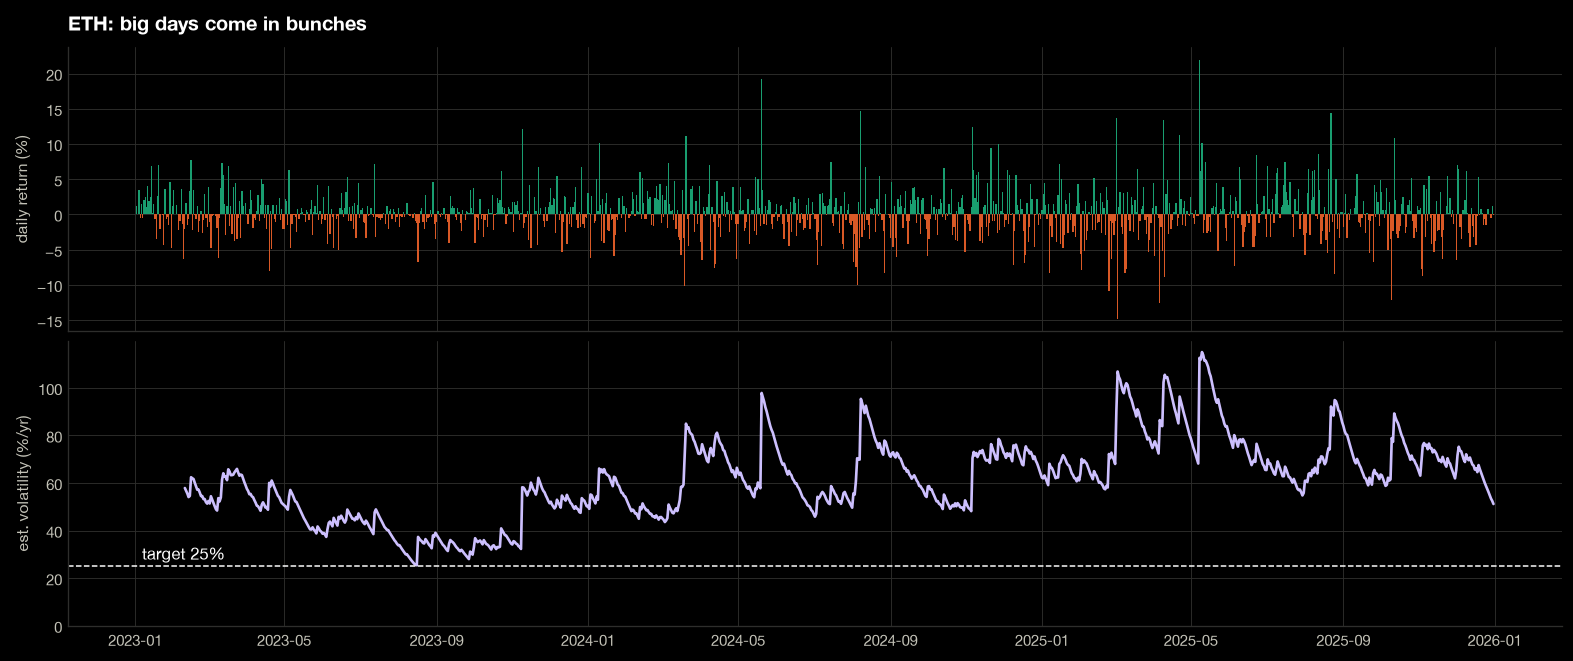

In [3]:
def est_vol(r: pd.Series | pd.DataFrame, span: int = SPAN) -> pd.Series | pd.DataFrame:
    """Annualised EWM volatility of daily returns, known at each close."""
    return r.ewm(span=span, min_periods=span).std() * np.sqrt(ANN)


vol = est_vol(rets)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 5.4), sharex=True, layout="constrained",
                              gridspec_kw={"height_ratios": [1, 1]})
r = rets.iloc[1:] * 100
ax.bar(r.index, r, width=1.0, color=np.where(r < 0, plots.color(1), plots.color(2)), lw=0)
ax.set_ylabel("daily return (%)")
ax.set_title(f"{NAME}: big days come in bunches")
ax2.plot(vol.index, vol * 100, color=VT_COLOR, lw=1.6)
ax2.axhline(TARGET * 100, color=plt.rcParams["text.color"], lw=0.9, ls="--")
ax2.annotate(f"target {TARGET:.0%}", (vol.index[0], TARGET * 100), xytext=(4, 4),
             textcoords="offset points")
ax2.set_ylabel("est. volatility (%/yr)")
ax2.set_ylim(bottom=0)
plt.show()

The test that matters: sort the days into five equal groups by the estimate, and for
each group measure the volatility that actually happened over the next 30 days. If the
estimate knew nothing, every row would show the same future volatility.

In [4]:
future = rets[::-1].rolling(HORIZON).std()[::-1].shift(-1) * np.sqrt(ANN)  # days t+1..t+30
fwd_ret = (close[ASSET].shift(-HORIZON) / close[ASSET] - 1)
fc = pd.DataFrame({"est_vol": vol, "next_vol": future, "next_ret": fwd_ret}).dropna()
fc["quintile"] = pd.qcut(fc.est_vol, 5, labels=["calmest", "2", "3", "4", "wildest"])
by_q = fc.groupby("quintile", observed=True).agg(
    est_vol=("est_vol", "mean"), next_vol=("next_vol", "mean"),
    next_ret=("next_ret", "mean"), days=("est_vol", "size"))
print(f"correlation of the estimate with the next {HORIZON} days' volatility: "
      f"{fc.est_vol.corr(fc.next_vol):.2f}; with the next {HORIZON} days' return: "
      f"{fc.est_vol.corr(fc.next_ret):.2f}")
bt.fmt_table(by_q, {"est_vol": "{:.0%}", "next_vol": "{:.0%}", "next_ret": "{:+.1%}",
                    "days": "{:.0f}"})

correlation of the estimate with the next 30 days' volatility: 0.41; with the next 30 days' return: -0.06


,est_vol,next_vol,next_ret,days
quintile,,,,
calmest,39%,45%,+4.6%,206
2,52%,62%,+7.5%,205
3,61%,66%,+2.1%,205
4,70%,67%,+2.8%,205
wildest,86%,68%,+1.2%,205


`est_vol` is the average estimate in each group, `next_vol` the average volatility over
the following 30 days and `next_ret` the average return over them. The forecast is
imperfect, since calm and wild periods both regress towards the middle, but the order
survives. The return column is the part it cannot forecast.

## The rule

On each close,

$$w_t = \min\!\left(\frac{\sigma_{\text{target}}}{\hat\sigma_t},\; 1\right)$$

of equity goes in the asset and $1 - w_t$ stays in cash, earning nothing. The cap at 1
means no borrowing: in calm markets the rule is simply fully invested, so it can only
ever hold less than buy and hold. The target is set at close $t$ and traded at close
$t+1$, so nothing is known before it happens.

Resizing every day would churn the book at 0.2% a fill, so a trade is only made when the
position has drifted more than 25% away from its target (a 60% target trades below 45%
or above 75%).

Two settings decide how visible the effect is:

* **The target, 25%.** Ether's own volatility runs at about 60%, so the rule holds well
  under half the book most of the time and the portfolio's risk is visibly flatter than
  the asset's. A target near the asset's own volatility (40% or more) leaves the rule
  fully invested much of the time and its curve barely separates from buy and hold.
* **The window, a 40-day span.** A faster estimate reacts to single big days: it cuts
  the day after a crash, often just before the rebound, and buys back once things calm
  down, paying fees both ways. Faster estimates, including ones built from hourly
  returns, forecast next month's volatility better but give worse results, because
  they trade on noise. From about 40 days up the results stop changing much (see the
  grid below and the other coins).

Both were chosen after seeing the grid and the other coins, so they are in-sample. The
constant-mix benchmark below, and the fact that every span from 40 to 90 days gives
similar results, are the checks against having picked a lucky number.

In [5]:
def vol_target(r: pd.Series, target: float = TARGET, span: int = SPAN,
               cap: float = MAX_W) -> pd.Series:
    """Share of equity in the asset: target / estimated vol, capped; 0 before the first
    estimate, so it sits in cash until then."""
    return (target / est_vol(r, span)).clip(upper=cap).fillna(0.0)


def run(w: pd.Series | pd.DataFrame, cfg: PortfolioConfig, px: pd.DataFrame = close) -> dict:
    w = w.to_frame(px.columns[0]) if isinstance(w, pd.Series) else w
    return bt.simulate(px, w, cfg, fee_bps=FEE, initial=INITIAL, warmup=WARMUP)


DAILY = PortfolioConfig(check_bars=1, band=BAND, band_all=True, min_trade_frac=0.0)
MONTHLY = PortfolioConfig(check_bars=MONTH, band=0.0, band_all=True, min_trade_frac=0.0)

w_vt = vol_target(rets)
res_vt = run(w_vt, DAILY)
held_vt = bt.held_weights(res_vt, close)[ASSET]
avg_w = held_vt.loc[span].mean()
print(f"average share held in {NAME}: {avg_w:.0%}; fully invested on "
      f"{(w_vt.loc[span] >= MAX_W).mean():.0%} of days")

average share held in ETH: 42%; fully invested on 0% of days


## The dashboard

Top: the volatility estimate against the target, shaded where it runs above. Bottom:
what the portfolio actually held, the risky asset against cash, after drift between
trades. Every rise in the top panel shows up as more cash in the bottom one.

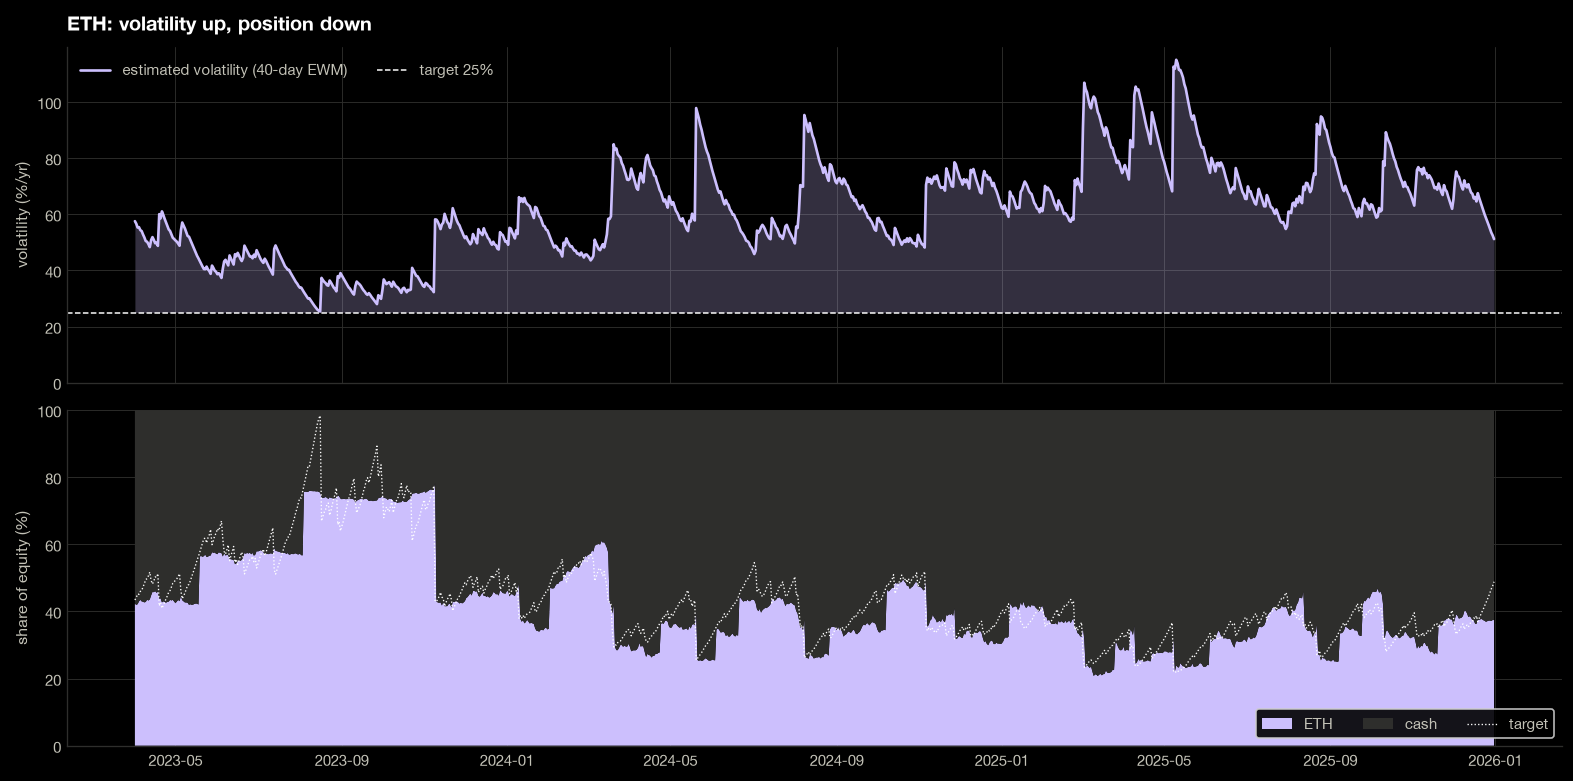

In [6]:
v, h = vol.loc[span] * 100, held_vt.loc[span] * 100

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True, layout="constrained")
ax.plot(v.index, v, color=VT_COLOR, lw=1.6, label=f"estimated volatility ({SPAN}-day EWM)")
ax.axhline(TARGET * 100, color=plt.rcParams["text.color"], lw=0.9, ls="--",
           label=f"target {TARGET:.0%}")
ax.fill_between(v.index, TARGET * 100, v, where=v > TARGET * 100, color=VT_COLOR,
                alpha=0.25, lw=0, interpolate=True)
ax.set_ylabel("volatility (%/yr)")
ax.set_ylim(bottom=0)
ax.set_title(f"{NAME}: volatility up, position down")
ax.legend(loc="upper left", ncol=2)

ax2.stackplot(h.index, h, 100 - h, colors=[VT_COLOR, CASH_COLOR],
              labels=[NAME, "cash"], lw=0)
ax2.plot(w_vt.loc[span].index, w_vt.loc[span] * 100, color=plt.rcParams["text.color"],
         lw=0.8, ls=":", label="target")
ax2.set_ylim(0, 100)
ax2.set_ylabel("share of equity (%)")
ax2.legend(loc="lower right", ncol=3, frameon=True, framealpha=0.9,
           facecolor=plt.rcParams["axes.facecolor"])
plt.show()

## Backtest

Three portfolios, all starting on the same day with the same money:

* **buy and hold**: everything in the asset, never traded again.
* **vol target**: the rule above, checked daily with the 25% band.
* **constant**: a fixed share of equity equal to the vol target's average holding,
  reset every 30 days. It holds as much of the asset on average as the vol target, but
  ignores volatility, so it separates the benefit of timing from that of just holding less.

In [7]:
const_w = pd.Series(round(avg_w, 2), index=close.index)
SCHEMES = {"vol target": (w_vt, DAILY),
           f"constant {const_w.iloc[0]:.0%}": (const_w, MONTHLY),
           "buy & hold": (pd.Series(1.0, index=close.index), MONTHLY)}
CONST = list(SCHEMES)[1]
COLORS = {"vol target": VT_COLOR, CONST: CONST_COLOR, "buy & hold": BH_COLOR}
runs = {k: run(w, cfg) for k, (w, cfg) in SCHEMES.items()}
held = {k: bt.held_weights(res, close)[ASSET] for k, res in runs.items()}
daily = {k: res["equity"].loc[span].pct_change().dropna() for k, res in runs.items()}


def row(k: str) -> dict:
    res, eq = runs[k], runs[k]["equity"].loc[span]
    return (bt.stats_from_result(res, k, WARMUP, ANN)
            | {"final_$": eq.iloc[-1], "fees_$": res["fees"], "avg_w": held[k].loc[span].mean(),
               "worst_day": daily[k].min(),
               "worst_30d": (eq / eq.shift(HORIZON) - 1).min()})


table = pd.DataFrame([row(k) for k in SCHEMES]).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "worst_day", "worst_30d",
                    "avg_w", "n_fills", "fees_$"]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "fees_$": "${:,.0f}", "avg_w": "{:.0%}",
              "worst_day": "{:+.1%}", "worst_30d": "{:+.1%}"})

,final_$,total_ret,sharpe,vol,max_dd,worst_day,worst_30d,avg_w,n_fills,fees_$
label,,,,,,,,,,
vol target,"$14,744",+47.6%,0.68,25%,-28.5%,-5.5%,-13.1%,42%,30,$102
constant 42%,"$13,810",+38.2%,0.57,27%,-32.8%,-5.9%,-14.1%,42%,34,$35
buy & hold,"$16,261",+62.9%,0.59,64%,-63.8%,-14.8%,-31.8%,100%,1,$20


`avg_w` is the average share of equity actually held in the asset, `worst_day` the
worst single day and `worst_30d` the worst 30-day stretch.

## Equity

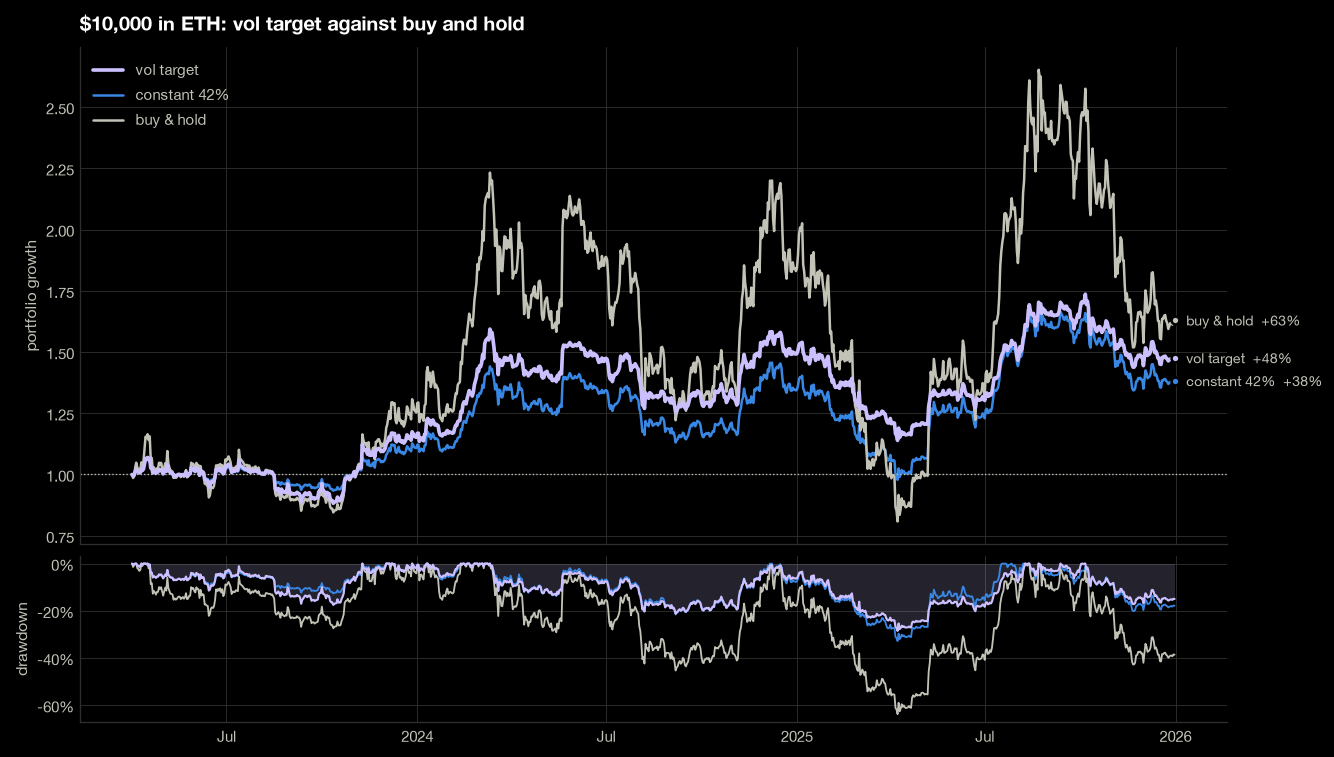

In [8]:
plots.equity_drawdown({k: runs[k]["equity"].loc[span] for k in SCHEMES},
                      f"${INITIAL:,.0f} in {NAME}: vol target against buy and hold",
                      colors=list(COLORS.values()), dd_for="vol target")
plt.show()

### Is the ride smoother?

Each portfolio's own volatility, measured over trailing 30-day windows. Buy and hold
passes the asset's swings straight through; the vol target's should sit near the
target line whatever the market does. The constant mix is smaller than buy and hold
but just as uneven.

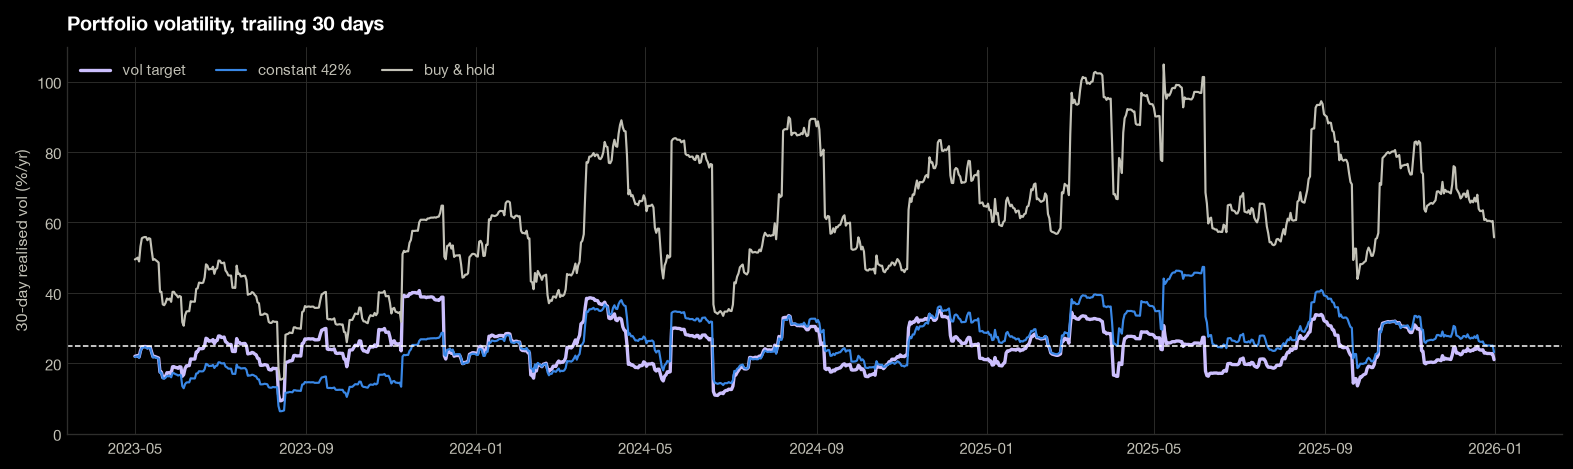

,min,10%,50%,90%,max
vol target,9%,18%,24%,33%,41%
constant 42%,6%,15%,26%,36%,47%
buy & hold,15%,36%,61%,89%,105%


In [9]:
fig, ax = plt.subplots(figsize=(13, 3.8), layout="constrained")
for k, r in daily.items():
    rv = r.rolling(HORIZON).std() * np.sqrt(ANN) * 100
    ax.plot(rv.index, rv, color=COLORS[k], lw=2.0 if k == "vol target" else 1.3, label=k)
ax.axhline(TARGET * 100, color=plt.rcParams["text.color"], lw=0.9, ls="--")
ax.set_ylabel("30-day realised vol (%/yr)")
ax.set_ylim(bottom=0)
ax.set_title("Portfolio volatility, trailing 30 days")
ax.legend(loc="upper left", ncol=3)
plt.show()

rv = pd.DataFrame({k: r.rolling(HORIZON).std() * np.sqrt(ANN) for k, r in daily.items()})
bt.fmt_table(rv.describe(percentiles=[0.1, 0.5, 0.9]).T[["min", "10%", "50%", "90%", "max"]],
             {c: "{:.0%}" for c in ["min", "10%", "50%", "90%", "max"]})

## The tail days

The 15 worst days for the asset in the trading period, and how much of the book the
vol target had in it going into each (its weight at the previous close). The rule
only steps aside on days that follow turbulence. A crash out of a calm market still
hits it fully invested.

In [10]:
N_TAIL = 15
asset_r = rets.loc[span].iloc[1:]
worst = asset_r.nsmallest(N_TAIL).index
w_in = held["vol target"].shift(1)
tails = pd.DataFrame({f"{NAME}": asset_r[worst], "est_vol_before": vol.shift(1)[worst],
                      "vt_weight": w_in[worst], "vol target": daily["vol target"][worst],
                      CONST: daily[CONST][worst]})
tails.index = tails.index.strftime("%Y-%m-%d")
print(f"average weight going in: {w_in[worst].mean():.0%} on these days, "
      f"{w_in.loc[span].mean():.0%} on all days")
print(f"summed loss on these {N_TAIL} days: buy & hold {asset_r[worst].sum():+.0%}, "
      f"vol target {daily['vol target'][worst].sum():+.0%}, "
      f"{CONST} {daily[CONST][worst].sum():+.0%}")
bt.fmt_table(tails, {NAME: "{:+.1%}", "est_vol_before": "{:.0%}", "vt_weight": "{:.0%}",
                     "vol target": "{:+.1%}", CONST: "{:+.1%}"})

average weight going in: 35% on these days, 42% on all days
summed loss on these 15 days: buy & hold -145%, vol target -51%, constant 42% -60%


,ETH,est_vol_before,vt_weight,vol target,constant 42%
ts,,,,,
2025-03-03,-14.8%,90%,35%,-5.2%,-5.9%
2025-04-06,-12.5%,72%,28%,-3.6%,-5.0%
2025-10-10,-12.2%,62%,45%,-5.5%,-5.0%
2025-02-24,-10.8%,58%,38%,-4.1%,-4.6%
2024-03-19,-10.1%,59%,42%,-4.2%,-4.6%
2024-08-05,-10.0%,61%,38%,-3.8%,-3.7%
2025-04-10,-8.8%,102%,36%,-3.2%,-3.4%
2025-11-04,-8.7%,69%,31%,-2.7%,-3.5%
2025-08-25,-8.4%,88%,27%,-2.3%,-3.7%


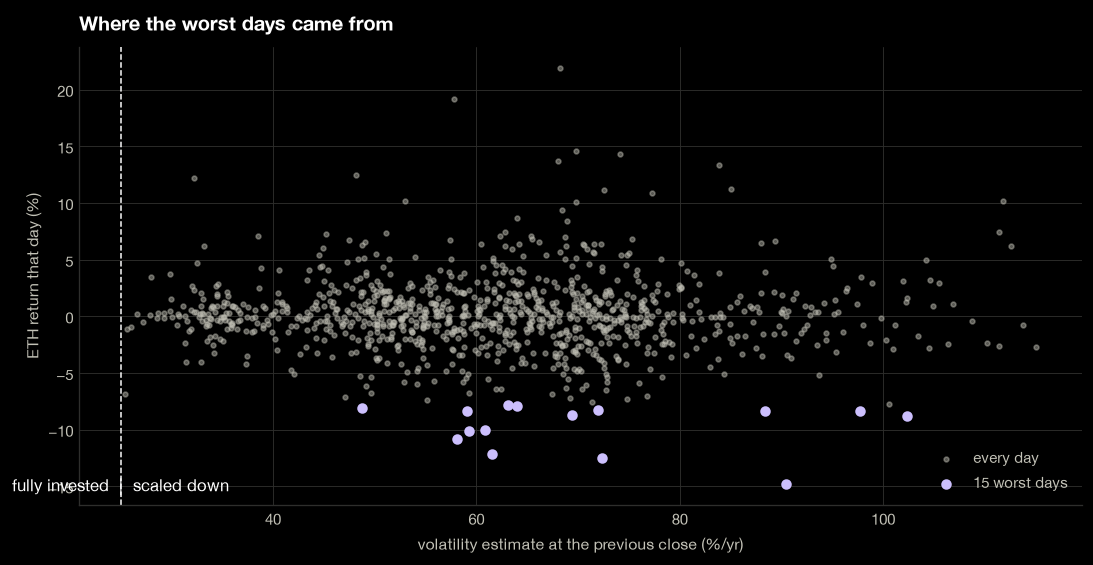

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6), layout="constrained")
ax.scatter(vol.shift(1).loc[asset_r.index] * 100, asset_r * 100, s=8, alpha=0.45,
           color=BH_COLOR, label="every day")
ax.scatter(vol.shift(1)[worst] * 100, asset_r[worst] * 100, s=28, color=VT_COLOR,
           label=f"{N_TAIL} worst days", zorder=3)
ax.axvline(TARGET * 100, color=plt.rcParams["text.color"], lw=0.9, ls="--")
ax.annotate("fully invested  |  scaled down", (TARGET * 100, ax.get_ylim()[0]),
            xytext=(0, 8), textcoords="offset points", ha="center")
ax.set_xlabel("volatility estimate at the previous close (%/yr)")
ax.set_ylabel(f"{NAME} return that day (%)")
ax.set_title("Where the worst days came from")
ax.legend(loc="lower right")
plt.show()

## Target and window settings

The vol target for more targets and estimation windows. A short window reacts fast but
is noisy, so it trades more; a long one is smooth but late. A high target is fully
invested most of the time and converges on buy and hold.

buy & hold, same days: return +63%, Sharpe 0.59, vol 64%, max drawdown -64%


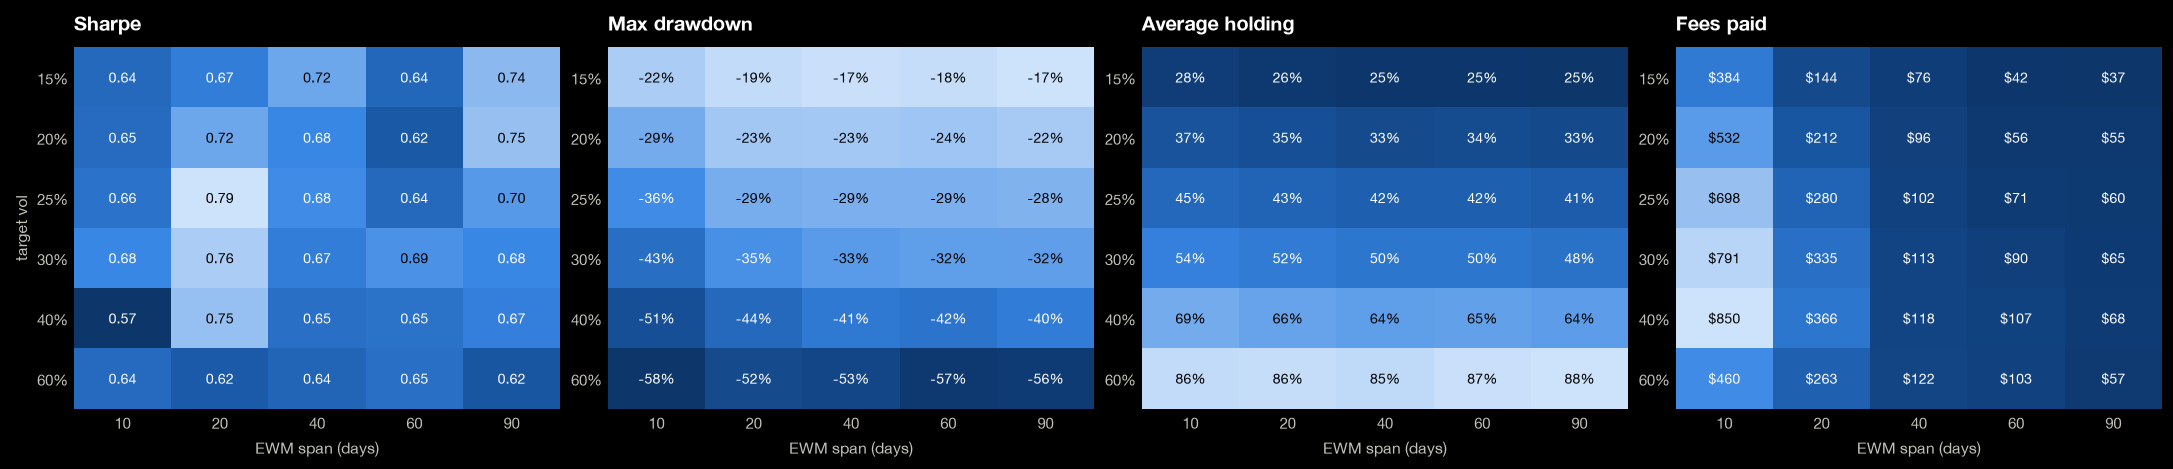

In [12]:
TARGETS = [0.15, 0.2, 0.25, 0.3, 0.4, 0.6]
SPANS = [10, 20, 40, 60, 90]

cells = []
for tgt in TARGETS:
    for s in SPANS:
        res = run(vol_target(rets, tgt, s), DAILY)
        st = bt.stats_from_result(res, "", WARMUP, ANN)
        cells.append({"target": f"{tgt:.0%}", "span": s, "fees": res["fees"],
                      "avg_w": bt.held_weights(res, close)[ASSET].loc[span].mean(),
                      **{m: st[m] for m in ("total_ret", "sharpe", "vol", "max_dd")}})
grid = pd.DataFrame(cells)
b = table.loc["buy & hold"]
print(f"buy & hold, same days: return {b.total_ret:+.0%}, Sharpe {b.sharpe:.2f}, "
      f"vol {b.vol:.0%}, max drawdown {b.max_dd:.0%}")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), layout="constrained")
for ax, (m, fmt, title) in zip(axes, [("sharpe", "{:.2f}", "Sharpe"),
                                      ("max_dd", "{:.0%}", "Max drawdown"),
                                      ("avg_w", "{:.0%}", "Average holding"),
                                      ("fees", "${:,.0f}", "Fees paid")]):
    plots.heatmap(grid.pivot(index="target", columns="span", values=m), title, fmt=fmt, ax=ax,
                  xlabel="EWM span (days)", ylabel="target vol" if ax is axes[0] else "")
plt.show()

### The band

The same rule with narrower and wider no-trade bands. Without a band the position is
resized nearly every day for small changes in the estimate.

In [13]:
BANDS = [0.0, 0.05, 0.1, 0.25, 0.5]
rows = []
for band in BANDS:
    res = run(w_vt, PortfolioConfig(check_bars=1, band=band, band_all=True, min_trade_frac=0.0))
    st = bt.stats_from_result(res, f"±{band:.0%}", WARMUP, ANN)
    rows.append(st | {"fees_$": res["fees"]})
bands = pd.DataFrame(rows).set_index("label")
bt.fmt_table(bands[["total_ret", "sharpe", "vol", "max_dd", "n_fills", "fees_$", "turnover"]],
             {**bt.PERF_FMT, "fees_$": "${:,.0f}"})

,total_ret,sharpe,vol,max_dd,n_fills,fees_$,turnover
label,,,,,,,
±0%,+46.8%,0.65,27%,-29.3%,1006,$362,18.1x
±5%,+47.3%,0.66,27%,-29.3%,302,$287,14.4x
±10%,+47.6%,0.67,26%,-29.2%,130,$209,10.4x
±25%,+47.6%,0.68,25%,-28.5%,30,$102,5.1x
±50%,+46.8%,0.71,24%,-26.5%,6,$44,2.2x


## Other coins

Ether is one asset. Here the same three portfolios are run on every coin in the file
with a price on every day of the period, with the same target, window and band.

In [14]:
universe = data.load_universe(path=DATA, fmt="ohlcv")
every = data.daily_panel(universe, raw=data.load_bars("1d", path=DATA, fmt="ohlcv")).close
every = every.reindex(close.index)                     # the same days as above
pool = sorted(every.columns[every.notna().all()])
print(f"{len(pool)} coins with a full history: {', '.join(pool)}")

rows = []
for coin in pool:
    px = every[[coin]]
    r = px[coin].pct_change()
    w = vol_target(r)
    res = run(w, DAILY, px)
    a = bt.held_weights(res, px)[coin].loc[span].mean()
    st = {"vt": bt.stats_from_result(res, "", WARMUP, ANN),
          "const": bt.stats_from_result(run(pd.Series(a, index=px.index), MONTHLY, px),
                                        "", WARMUP, ANN),
          "bh": bt.stats_from_result(run(pd.Series(1.0, index=px.index), MONTHLY, px),
                                     "", WARMUP, ANN)}
    rows.append({"coin": coin, "asset_vol": r.loc[span].std() * np.sqrt(ANN), "avg_w": a,
                 **{f"{k}_{m}": s[m] for k, s in st.items()
                    for m in ("total_ret", "sharpe", "vol", "max_dd")}})
multi = pd.DataFrame(rows).set_index("coin")
multi["dd_cut"] = 1 - multi.vt_max_dd / multi.bh_max_dd          # share of drawdown avoided
multi["beats_const"] = multi.vt_sharpe > multi.const_sharpe

med = multi.drop(columns="beats_const").median().to_frame("median").T
med["beats_const"] = multi.beats_const.mean()
print(f"median over {len(pool)} coins; beats_const is the share of coins where the vol "
      "target had a higher Sharpe than the constant mix of the same average size")
bt.fmt_table(med[["asset_vol", "avg_w", "bh_sharpe", "const_sharpe", "vt_sharpe", "bh_vol",
                  "vt_vol", "bh_max_dd", "const_max_dd", "vt_max_dd", "dd_cut", "beats_const"]],
             {**{c: "{:.2f}" for c in ("bh_sharpe", "const_sharpe", "vt_sharpe")},
              **{c: "{:.0%}" for c in ("asset_vol", "avg_w", "bh_vol", "vt_vol", "bh_max_dd",
                                       "const_max_dd", "vt_max_dd", "dd_cut", "beats_const")}})

24 coins with a full history: aave, ada, algo, atom, avax, bch, btc, doge, dot, etc, eth, icp, link, ltc, near, qnt, shib, sol, trx, uni, xlm, xmr, xrp, zec
median over 24 coins; beats_const is the share of coins where the vol target had a higher Sharpe than the constant mix of the same average size


,asset_vol,avg_w,bh_sharpe,const_sharpe,vt_sharpe,bh_vol,vt_vol,bh_max_dd,const_max_dd,vt_max_dd,dd_cut,beats_const
median,88%,33%,0.52,0.47,0.61,88%,26%,-66%,-32%,-24%,62%,75%


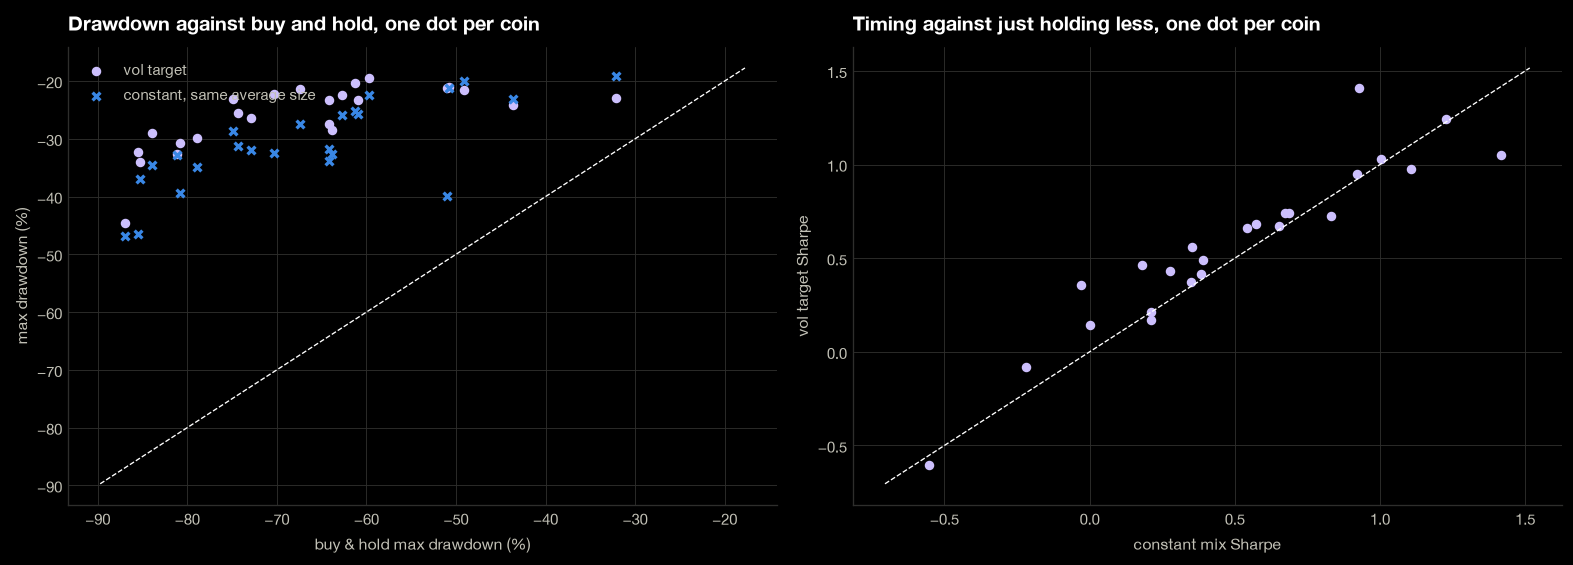

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), layout="constrained")
axes[0].scatter(multi.bh_max_dd * 100, multi.vt_max_dd * 100, s=22, color=VT_COLOR,
                label="vol target")
axes[0].scatter(multi.bh_max_dd * 100, multi.const_max_dd * 100, s=22, color=CONST_COLOR,
                marker="x", label="constant, same average size")
axes[1].scatter(multi.const_sharpe, multi.vt_sharpe, s=22, color=VT_COLOR)
for ax in axes:
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], color=plt.rcParams["text.color"], lw=0.8, ls="--")
axes[0].set_xlabel("buy & hold max drawdown (%)")
axes[0].set_ylabel("max drawdown (%)")
axes[0].set_title("Drawdown against buy and hold, one dot per coin")
axes[0].legend(loc="upper left")
axes[1].set_xlabel("constant mix Sharpe")
axes[1].set_ylabel("vol target Sharpe")
axes[1].set_title("Timing against just holding less, one dot per coin")
plt.show()

Reading the results: TODO

## Video: buy and hold against the vol target

A five-second opener shows the rule being worked out: daily returns, the
volatility estimate against the target, and the share held that follows, each under
its formula. Then the two equity curves race from the same start, with drawdowns and fees paid
underneath. The vol target is drawn on top in violet with its drawdown filled; buy and
hold is the dimmer grey line.

In [16]:
import os
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.png"
font = FONT if FONT.exists() else None
icon = ICON if ICON.exists() else None

AUDIO = PROJECT_ROOT / ".audio" / "Blanco_ft_Nemzzz_-_Brilliant_Mind_II_Official_Music_Video.mp3"
AUDIO_START = 0.0            # seconds into the track to start from

RACE = ["vol target", "buy & hold"]
fees_paid = {k: runs[k]["fills"].groupby("ts").fee.sum().reindex(span, fill_value=0).cumsum()
             for k in RACE}                     # cumulative, in dollars
t_v, t_b = table.loc["vol target"], table.loc["buy & hold"]
LAMBDA = 1 - 2 / (SPAN + 1)                     # the EWM decay pandas uses for this span
FORMULAS = [
    (r"$r_t = P_t \,/\, P_{t-1} - 1$", "daily return"),
    (r"$\hat\sigma_t^2 = \lambda\,\hat\sigma_{t-1}^2 + (1-\lambda)\,r_t^2$",
     rf"$\lambda$ = {LAMBDA:.2f}, annualised ×√{ANN:.0f}"),
    (r"$w_t = \min\left(\sigma_{\mathrm{target}} \,/\, \hat\sigma_t,\ 1\right)$",
     f"share in {NAME}, rest in cash"),
]
out = PROJECT_ROOT / ".media" / "vol_target.mp4"

with tempfile.TemporaryDirectory() as tmp:
    intro = animate.vol_explainer(
        rets.loc[span], vol.loc[span], held_vt.loc[span], TARGET, Path(tmp) / "intro.mp4",
        title="How much to hold",
        subtitle=f"{NAME}, daily · {SPAN}-day EWM volatility · {TARGET:.0%} target",
        formulas=FORMULAS, seconds=3.5, hold=1.5, font=font, icon=icon, progress=False)
    race = animate.equity_race(
        {k: runs[k]["equity"].loc[span] for k in RACE}, Path(tmp) / "race.mp4",
        title="Less risk when it's rough",
        subtitle=f"${INITIAL:,.0f} in {NAME} · {TARGET:.0%} vol target, rest in cash · "
                 f"{FEE / 100:g}% fee",
        caption=f"Worst drop {t_b.max_dd:.0%} → {t_v.max_dd:.0%}. "
                f"Volatility {t_b.vol:.0%} → {t_v.vol:.0%}.",
        log=False, colors=[VT_COLOR, BH_VIDEO], dd_for="vol target", seconds=16,
        fees=fees_paid, drawdown=True, font=font, icon=icon, progress=False)
    video = animate.concat([intro, race], out, audio=AUDIO if AUDIO.exists() else None,
                           audio_start=AUDIO_START)

Video(os.path.relpath(video), embed=False, width=540)